# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 7.6+ KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

region:
        count  proportion
region                   
West       47       0.294
East       42       0.262
South      36       0.225
North      35       0.219



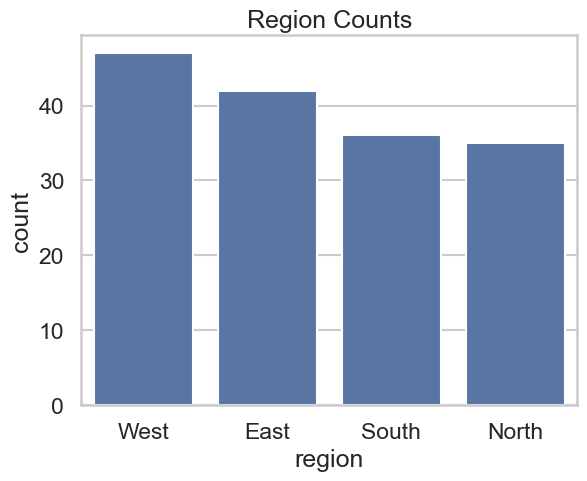

In [5]:
# Value counts + proportions for every non-numeric column (the date axis is
# handled separately in section 4b).
cat_cols = [c for c in df.select_dtypes(exclude='number').columns if c != 'date']
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    props = df[col].value_counts(dropna=False, normalize=True).round(3)
    print(f'{col}:')
    print(pd.DataFrame({'count': counts, 'proportion': props}))
    print()

sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title('Region Counts')
plt.show()

## 3) Distributions — two worked examples below; add at least one more

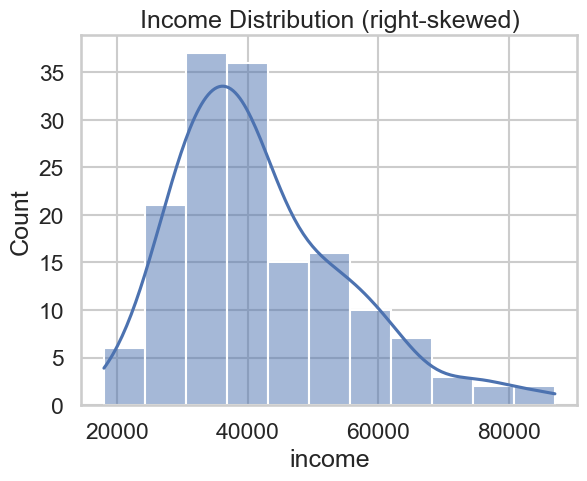

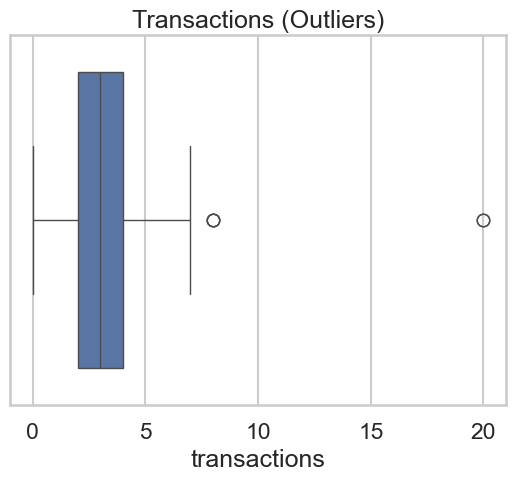

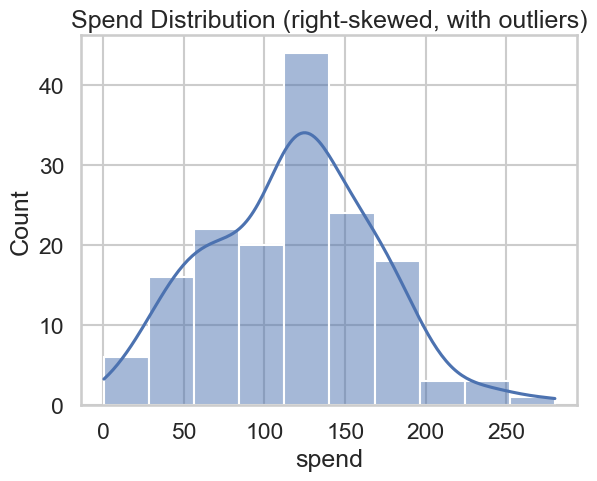

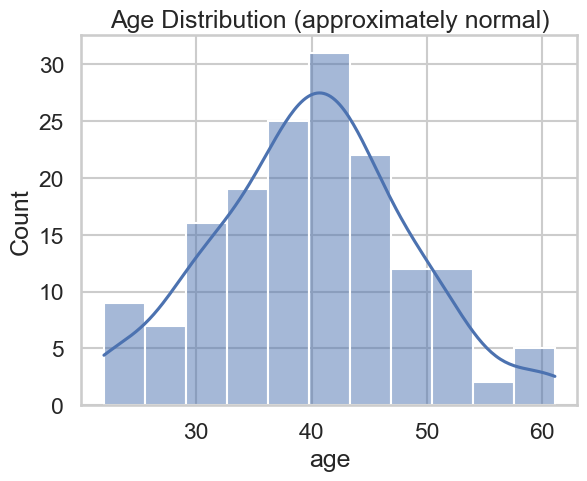

In [6]:
# Example 1 of 3 — histogram + KDE on a skewed column.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution (right-skewed)')
plt.show()

# Example 2 of 3 — boxplot to expose outliers.
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

# Example 3 of 3 — spend is also right-skewed with a few large values.
sns.histplot(df['spend'], kde=True)
plt.title('Spend Distribution (right-skewed, with outliers)')
plt.show()

# Bonus — age is approximately normal, contrasting with the skewed columns above.
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution (approximately normal)')
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

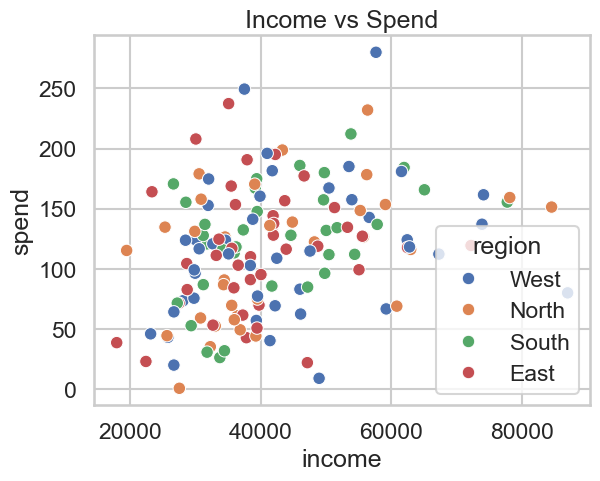

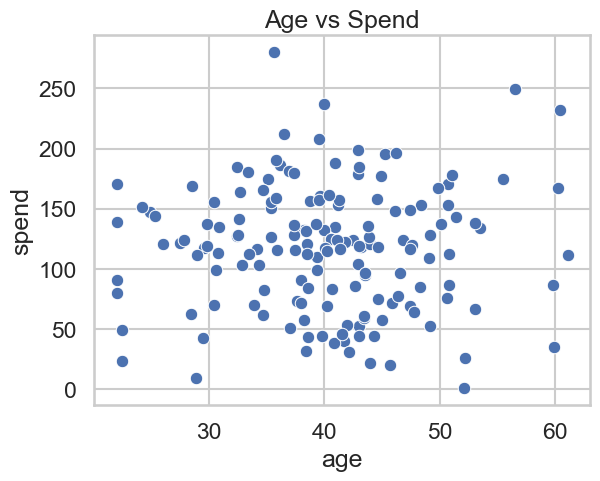

In [7]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

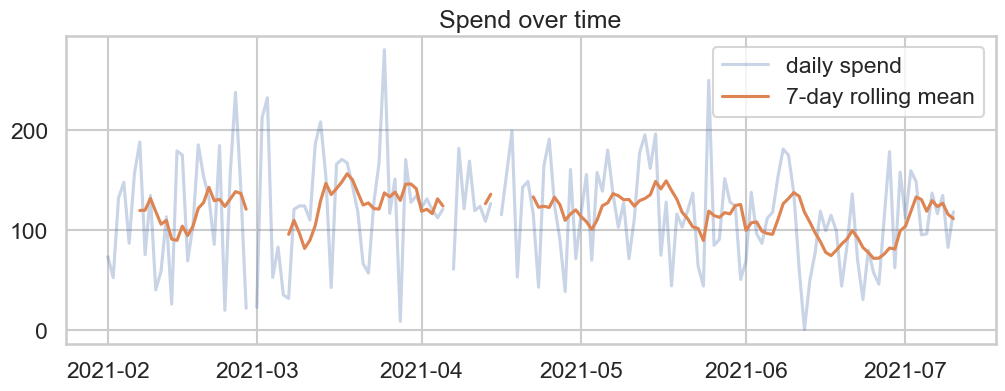

Days between consecutive rows:
date
1.0    159
NaN      1
Name: count, dtype: int64


In [8]:
# Sort by date and set it as the index — order matters for line/rolling plots.
ts = df.sort_values('date').set_index('date')

# Spend over time: raw daily + a 7-day rolling mean to smooth noise.
ts['spend_roll7'] = ts['spend'].rolling(7).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts['spend'], alpha=0.3, label='daily spend')
ax.plot(ts.index, ts['spend_roll7'], label='7-day rolling mean')
ax.set_title('Spend over time')
ax.legend()
plt.show()

# Gap check: is the date axis continuous? A rolling window over a gap is misleading.
diffs = ts.index.to_series().diff().dt.days
print('Days between consecutive rows:')
print(diffs.value_counts(dropna=False).sort_index())

### What the time series shows

- **No trend and no seasonality** — spend fluctuates around a stable level, and
  the 7-day rolling mean stays flat. The occasional spikes are the injected
  outliers, not a seasonal cycle.
- **No gaps** — every consecutive pair of rows is 1 day apart, so the date axis
  is continuous and rolling windows are trustworthy.
- **Implication for stages 09/10b** — because this synthetic series has no time
  structure, lag/rolling features (stage 09) and a time-based train/test split
  (stage 10b) have little to exploit beyond the fact that the ordering is clean.
  A real dataset with a trend or level shift would need detrending first.

## 5) (Optional) Correlation matrix

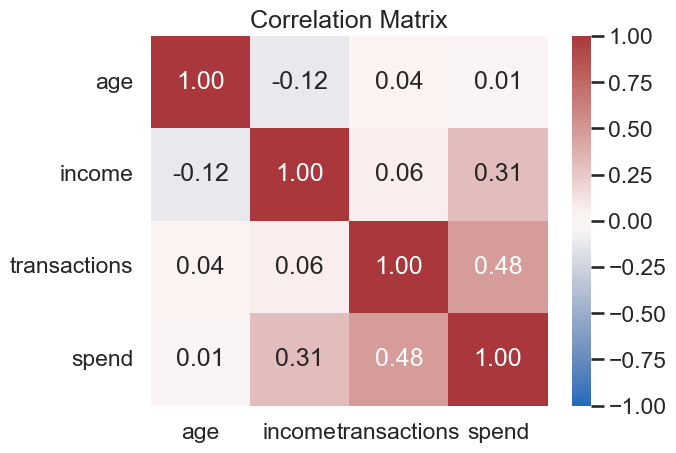

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [9]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [10]:
import sys
from pathlib import Path
from IPython.display import display
# make src/ importable when this notebook is run from homework08/
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from src.eda import eda_summary, flag_columns

display(eda_summary(df))
print('Columns needing attention:', flag_columns(df))

,dtype,n_missing,pct_missing,n_unique,mean,std,min,max
date,datetime64[ns],0,0.0000,160,NaN,NaN,NaN,NaN
region,object,0,0.0000,4,NaN,NaN,NaN,NaN
age,float64,0,0.0000,122,40.0187,8.4587,22.00,61.10
income,float64,5,0.0312,155,41983.8663,13262.4570,17928.80,87052.40
transactions,int64,0,0.0000,10,3.2375,2.5856,0.00,20.00
spend,float64,3,0.0187,156,117.2916,51.7686,0.54,280.05


Columns needing attention: []


## 6) Insights & Assumptions

### Top 3 insights
1. **`income` and `spend` are right-skewed with outliers.** Their histograms are
   long-tailed and skew/kurtosis in section 2 confirm it. `spend` is built from
   `income`, so handling `income` outliers cascades into `spend`.
2. **`transactions` has two extreme outliers** (max + 12) that dominate its boxplot
   and inflate its variance — these should be flagged/winsorized before any
   variance- or distance-based model, or they will distort it.
3. **`region` is balanced, and `date` carries no signal.** The four regions are
   roughly even, so `region` is usable as a categorical feature; the time axis has
   no trend/seasonality/gaps, so stage 09 lag/rolling features add little here.

### Assumptions & risks
- Missingness (5 rows of `income`, 3 of `spend`) is assumed MCAR; median
  imputation (stage 06) is the planned treatment.
- The synthetic generator is seeded, so results are reproducible, but they reflect
  an artificial schema — a real dataset needs the same pass.
- Normality assumptions for z-score outlier tests do not hold for the skewed
  columns, so IQR-based handling is preferred.

### Next steps before modeling (cleaning & features)
- Impute `income`/`spend` missing values and winsorize (not drop) the
  `transactions`/`spend` outliers.
- Engineer `spend_income_ratio` and a categorical encoding of `region` in stage 09.
- Re-check skew after log-transforming the skewed features.